Matplotlib is building the font cache; this may take a moment.


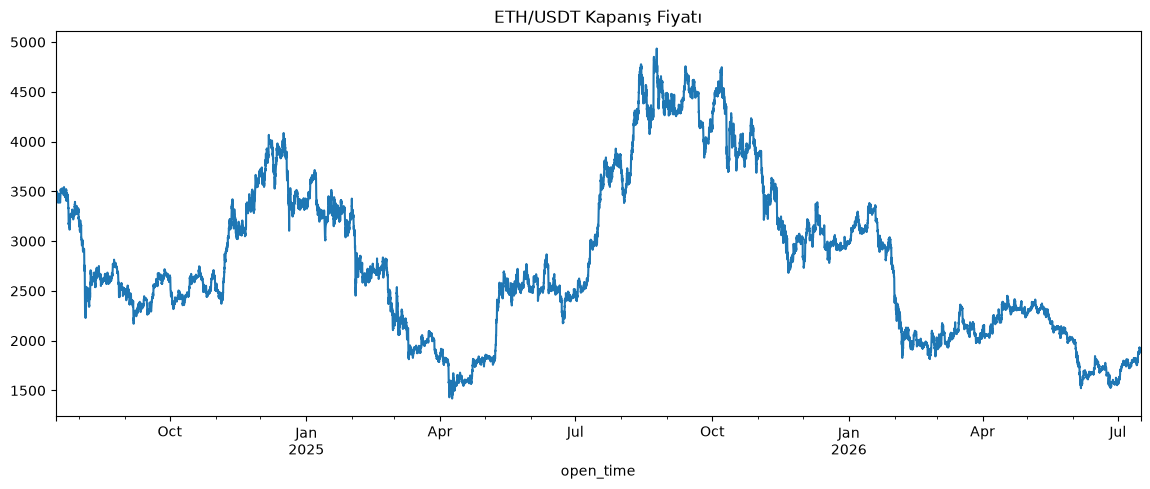

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ETHUSDT.csv", parse_dates=["open_time"])
df.set_index("open_time", inplace=True)

df["close"].plot(figsize=(14,5), title="ETH/USDT Kapanış Fiyatı")
plt.show()

In [2]:
print(df.isna().sum())
print(df.describe())

open      0
high      0
low       0
close     0
volume    0
dtype: int64
               open          high           low         close         volume
count  17520.000000  17520.000000  17520.000000  17520.000000   17520.000000
mean    2799.358961   2812.870841   2785.046282   2799.272398   20162.171130
std      790.839369    794.271256    787.068068    790.856915   22897.350611
min     1418.790000   1426.630000   1385.050000   1418.800000     909.852900
25%     2179.227500   2188.897500   2164.690000   2179.060000    7881.327475
50%     2629.200000   2641.750000   2617.770000   2629.155000   13394.514300
75%     3325.962500   3341.960000   3308.347500   3325.932500   23982.900375
max     4935.010000   4956.780000   4897.310000   4935.000000  508838.404900


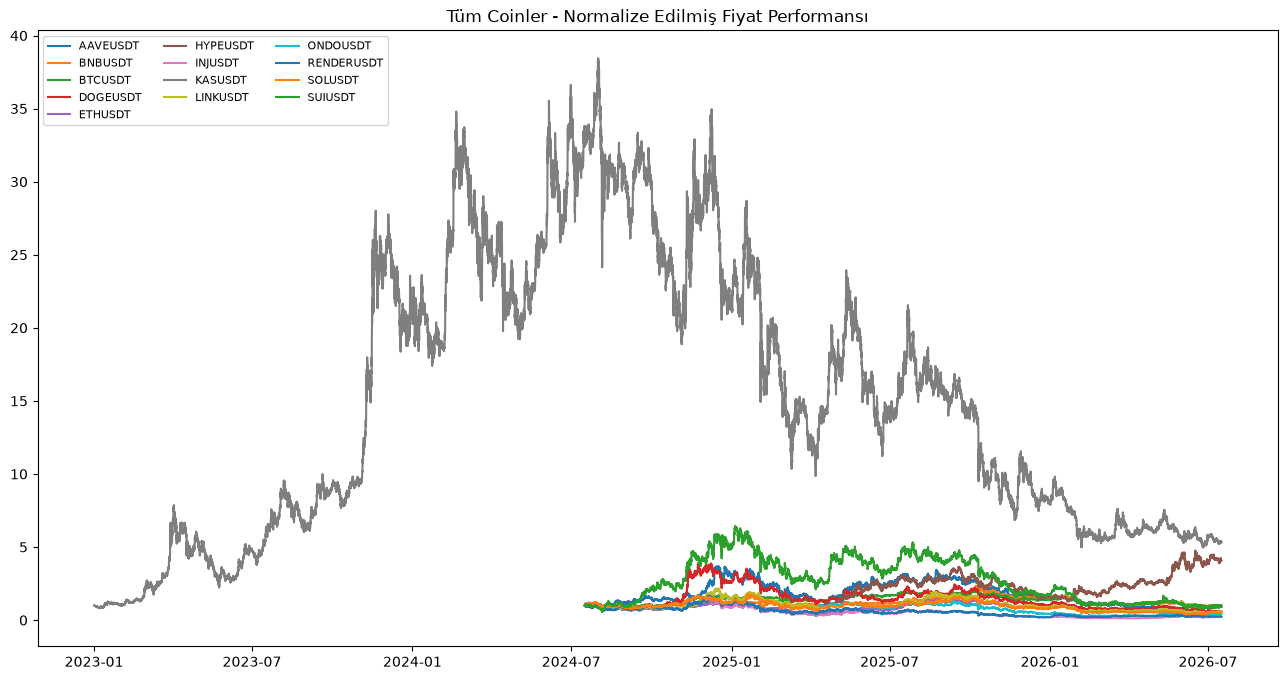

In [3]:
import os

fig, ax = plt.subplots(figsize=(16,8))
for file in os.listdir("../data"):
    symbol = file.replace(".csv", "")
    d = pd.read_csv(f"../data/{file}", parse_dates=["open_time"])
    d.set_index("open_time", inplace=True)
    normalized = d["close"] / d["close"].iloc[0]  # ilk değere göre normalize
    ax.plot(normalized, label=symbol)

ax.legend(loc="upper left", ncol=3, fontsize=8)
ax.set_title("Tüm Coinler - Normalize Edilmiş Fiyat Performansı")
plt.show()

In [4]:
import sys
sys.path.append("..")
from src.features import add_features

df_feat = add_features(df)
print(df_feat.shape)
df_feat.head()

(17486, 22)


,open,high,low,close,volume,rsi,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,...,BBB_20_2.0_2.0,BBP_20_2.0_2.0,atr,close_lag_1,close_lag_2,close_lag_3,rolling_mean_7,rolling_std_7,rolling_mean_30,target
open_time,,,,,,,,,,,,,,,,,,,,,
2024-07-17 19:00:00,3417.50,3427.64,3412.51,3416.79,8177.3285,44.651569,-6.334296,-11.304730,4.970434,3400.588339,...,3.547558,0.131918,29.793009,3417.49,3408.49,3401.78,3429.481429,25.130797,3457.945333,3415.93
2024-07-17 20:00:00,3416.79,3428.40,3412.68,3415.93,5154.5242,44.414871,-7.662022,-10.105965,2.443943,3394.812328,...,3.742435,0.163107,28.787794,3416.79,3417.49,3408.49,3422.071429,18.798552,3458.020667,3412.39
2024-07-17 21:00:00,3415.93,3419.00,3389.78,3412.39,9062.6650,43.395130,-8.897340,-9.073026,0.175686,3388.983195,...,3.881153,0.174502,28.818666,3415.93,3416.79,3417.49,3415.720000,10.970489,3455.892000,3395.18
2024-07-17 22:00:00,3412.39,3415.77,3390.27,3395.18,6128.2100,38.738551,-11.136665,-9.049881,-2.086784,3380.462528,...,4.139733,0.102991,28.581619,3412.39,3415.93,3416.79,3409.721429,8.485467,3453.545000,3387.05
2024-07-17 23:00:00,3395.18,3406.20,3385.50,3387.05,4481.9086,36.733249,-13.412756,-9.060777,-4.351979,3371.553601,...,4.391840,0.102356,28.018646,3395.18,3412.39,3415.93,3407.617143,11.916027,3451.152000,3410.68


In [5]:
df_feat[["close", "rsi", "MACD_12_26_9", "atr", "rolling_mean_7"]].tail(10)

,close,rsi,MACD_12_26_9,atr,rolling_mean_7
open_time,,,,,
2026-07-15 23:00:00,1917.86,62.329249,17.294954,14.397359,1923.371429
2026-07-16 00:00:00,1914.86,60.023165,15.829776,14.323976,1921.502857
2026-07-16 01:00:00,1922.70,63.793258,15.126861,14.577978,1921.250000
2026-07-16 02:00:00,1925.37,65.003705,14.616750,14.055265,1921.424286
2026-07-16 03:00:00,1918.70,59.639681,13.518438,13.902746,1920.702857
2026-07-16 04:00:00,1918.31,59.331390,12.472769,13.398979,1920.175714
2026-07-16 05:00:00,1925.66,63.192957,12.097699,13.192623,1920.494286
2026-07-16 06:00:00,1922.53,60.556000,11.416287,13.244578,1921.161429
2026-07-16 07:00:00,1910.63,51.719572,9.803031,13.551394,1920.557143
